In [1]:
!pip install -q torch_snippets fastprogress

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 1.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.3/110.3 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.5/170.5 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.5/226.5 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.4/99.4 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 76.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 469.0/469.0 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 71.6 MB/s eta 0:00:00


In [2]:
from torch_snippets import *
from torchvision.datasets import MNIST
from torchvision import transforms

# define o dispositivo
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cpu


In [3]:
# normaliza pixels para e move para o dispositivo
img_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
    transforms.Lambda(lambda x: x.to(device))
])

# carrega o MNIST e cria os dataloaders
trn_ds = MNIST('./content/', transform=img_transform, train=True,  download=True)
val_ds = MNIST('./content/', transform=img_transform, train=False, download=True)
trn_dl = DataLoader(trn_ds, batch_size=128, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=128, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 44.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.07MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.62MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.50MB/s]


In [5]:
# autoencoder convolucional
class ConvAutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1), nn.ReLU(True),
            nn.MaxPool2d(2, stride=2),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU(True),
            nn.MaxPool2d(2, stride=1)
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 3, stride=2), nn.ReLU(True), # expande
            nn.ConvTranspose2d(32, 16, 5, stride=2, padding=1), nn.ReLU(True), # expande
            nn.ConvTranspose2d(16,  1, 2, stride=2, padding=1), nn.Tanh() # volta para 28x28
        )

    def forward(self, x):
        x = self.encoder(x) # comprime
        x = self.decoder(x) # reconstrói
        return x

model = ConvAutoEncoder().to(device)
print(model)

ConvAutoEncoder(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=1, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2))
    (1): ReLU(inplace=True)
    (2): ConvTranspose2d(32, 16, kernel_size=(5, 5), stride=(2, 2), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): ConvTranspose2d(16, 1, kernel_size=(2, 2), stride=(2, 2), padding=(1, 1))
    (5): Tanh()
  )
)


In [6]:
# treina um batch
def train_batch(input, model, criterion, optimizer):
    model.train()
    optimizer.zero_grad() # zera gradientes
    output = model(input) # gera reconstrução
    loss = criterion(output, input) # compara com original
    loss.backward() # backward pass
    optimizer.step() # atualiza os pesos
    return loss

# valida sem atualizar pesos
@torch.no_grad()
def validate_batch(input, model, criterion):
    model.eval()
    output = model(input)
    return criterion(output, input)

In [8]:
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-5)

In [10]:
from fastprogress import master_bar, progress_bar

# loop de treinamento
num_epochs = 5
log = master_bar(range(num_epochs))
for epoch in log:
    for data, _ in progress_bar(trn_dl, parent=log): # treino
        loss = train_batch(data, model, criterion, optimizer)
        log.child.comment = f'Treino Loss: {loss:.4f}'

    for data, _ in progress_bar(val_dl, parent=log): # validação
        loss = validate_batch(data, model, criterion)
        log.child.comment = f'Val Loss: {loss:.4f}'

    log.write(f'Época {epoch+1}/{num_epochs}')

<div><p>Época 1/5</p><p>Época 2/5</p><p>Época 3/5</p><p>Época 4/5</p><p>Época 5/5</p></div>

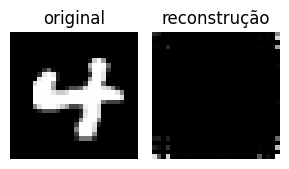

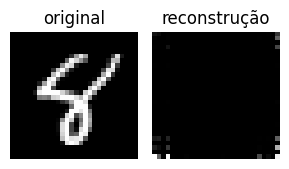

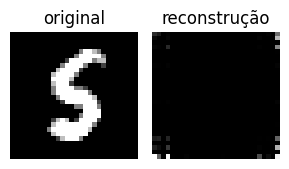

In [11]:
# compara 3 imagens
import matplotlib.pyplot as plt
model.eval()
for _ in range(3):
    ix = np.random.randint(len(val_ds))
    im, _ = val_ds[ix]
    with torch.no_grad():
        _im = model(im[None])[0].cpu() # gera reconstrução
    fig, ax = plt.subplots(1, 2, figsize=(3, 3))
    show(im[0].cpu(), ax=ax[0], title='original')
    show(_im[0],      ax=ax[1], title='reconstrução')
    plt.tight_layout(); plt.show()

In [14]:
# extrai os vetores latentes
latent_vectors, classes = [], []
for im, clss in val_dl:
    with torch.no_grad():
        latent = model.encoder(im).view(im.size(0), -1)
    latent_vectors.append(latent.cpu())
    classes.append(clss)

latent_vectors = torch.cat(latent_vectors)
all_classes    = torch.cat(classes).numpy()

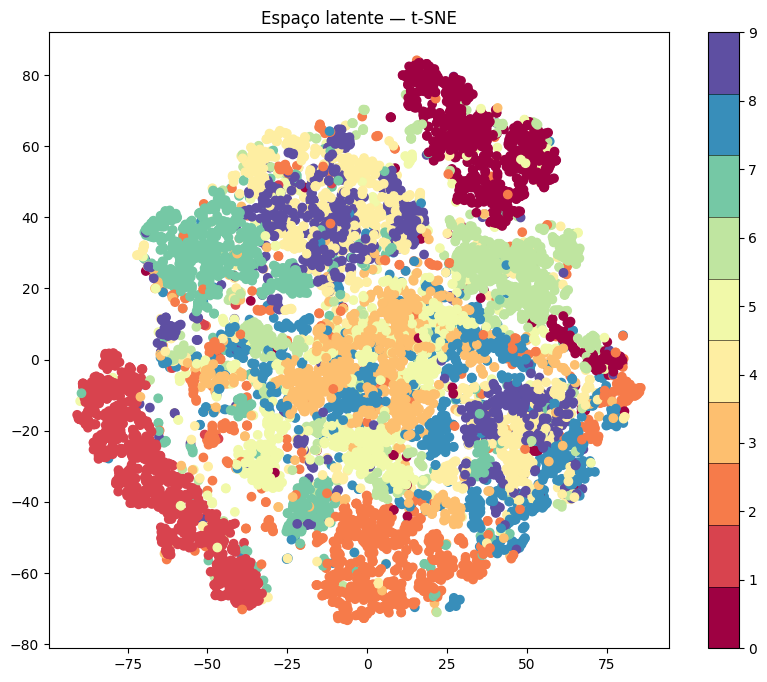

In [15]:
from sklearn.manifold import TSNE

clustered = TSNE(2).fit_transform(latent_vectors.numpy())
plt.figure(figsize=(10, 8))
cmap = plt.get_cmap('Spectral', 10)
plt.scatter(*zip(*clustered), c=all_classes, cmap=cmap)
plt.colorbar(drawedges=True)
plt.title('Espaço latente — t-SNE'); plt.show()